# 🐶 DogTalk AI — CS 5588 Week 14
**Theme:** Foundation Models for Speech, Music, and Sound AI

## System Overview
- **Pipeline A (Dog → Human):** Dog bark audio → wav2vec2 → Emotion classifier → Label
- **Pipeline B (Human → Dog):** Emotion text → Prompt engineering → AudioLDM2 → Bark audio

**Models used:**
- `facebook/wav2vec2-base-960h` (Hugging Face)
- `cvssp/audioldm2` (Hugging Face)
- Fine-tuned classification head (PyTorch)


## Step 0 — Install dependencies

In [1]:
!pip install -q transformers datasets torch torchaudio soundfile librosa matplotlib scikit-learn diffusers accelerate
!pip install -q ipython
print('✅ All packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.4 MB/s eta 0:00:00
✅ All packages installed


In [13]:
!pip install -q transformers==4.38.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 70.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.


## Step 1 — Imports & Setup

In [2]:
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from IPython.display import Audio, display
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Using device: {device}')

✅ Using device: cuda


## Pipeline A — Dog Bark → Emotion
### Step 2 — Load wav2vec2 feature extractor

In [3]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model

MODEL_NAME = 'facebook/wav2vec2-base-960h'
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
wav2vec2 = Wav2Vec2Model.from_pretrained(MODEL_NAME).to(device)
wav2vec2.eval()
print('✅ wav2vec2 loaded')

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ wav2vec2 loaded


### Step 3 — Simulate dog bark dataset (4 emotions × 10 samples)

In [4]:
import random

EMOTIONS = ['happy', 'anxious', 'alert', 'bored']
EMOTION_TO_IDX = {e: i for i, e in enumerate(EMOTIONS)}
IDX_TO_EMOTION = {i: e for i, e in enumerate(EMOTIONS)}

EMOTION_EMOJI = {
    'happy':   '😄',
    'anxious': '😰',
    'alert':   '⚡',
    'bored':   '😴'
}

def synthesize_bark(emotion: str, duration: float = 1.0, sr: int = 16000) -> np.ndarray:
    """
    Synthesize a simple dog-bark-like waveform per emotion.
    Each emotion has a characteristic frequency + rhythm profile.
    In a real project, replace this with an actual dog-bark dataset.
    """
    t = np.linspace(0, duration, int(sr * duration))
    if emotion == 'happy':
        # Short, high-pitched repeating bursts
        base = np.sin(2 * np.pi * 900 * t) * np.clip(np.sin(2 * np.pi * 6 * t), 0, 1)
        noise = np.random.normal(0, 0.05, len(t))
        wave = base + noise
    elif emotion == 'anxious':
        # Rapid, mid-range whimper-like signal
        base = np.sin(2 * np.pi * 600 * t) * np.clip(np.sin(2 * np.pi * 12 * t), 0, 1)
        noise = np.random.normal(0, 0.08, len(t))
        wave = base + noise
    elif emotion == 'alert':
        # Sharp single burst, deep
        envelope = np.exp(-5 * t)
        base = np.sin(2 * np.pi * 400 * t) * envelope
        noise = np.random.normal(0, 0.03, len(t))
        wave = base + noise
    else:  # bored
        # Low-amplitude, slow modulation
        base = np.sin(2 * np.pi * 300 * t) * 0.3
        noise = np.random.normal(0, 0.02, len(t))
        wave = base + noise

    wave = wave / (np.max(np.abs(wave)) + 1e-8)  # normalize
    return wave.astype(np.float32)

# Build dataset
dataset = []
for emotion in EMOTIONS:
    for _ in range(10):
        waveform = synthesize_bark(emotion, duration=random.uniform(0.8, 1.5))
        dataset.append({'waveform': waveform, 'label': EMOTION_TO_IDX[emotion], 'emotion': emotion})

random.shuffle(dataset)
print(f'✅ Dataset ready: {len(dataset)} samples across {len(EMOTIONS)} emotions')
print('Emotions:', ', '.join([f"{e} {EMOTION_EMOJI[e]}" for e in EMOTIONS]))

✅ Dataset ready: 40 samples across 4 emotions
Emotions: happy 😄, anxious 😰, alert ⚡, bored 😴


### Step 4 — Visualize sample barks (waveform + spectrogram)

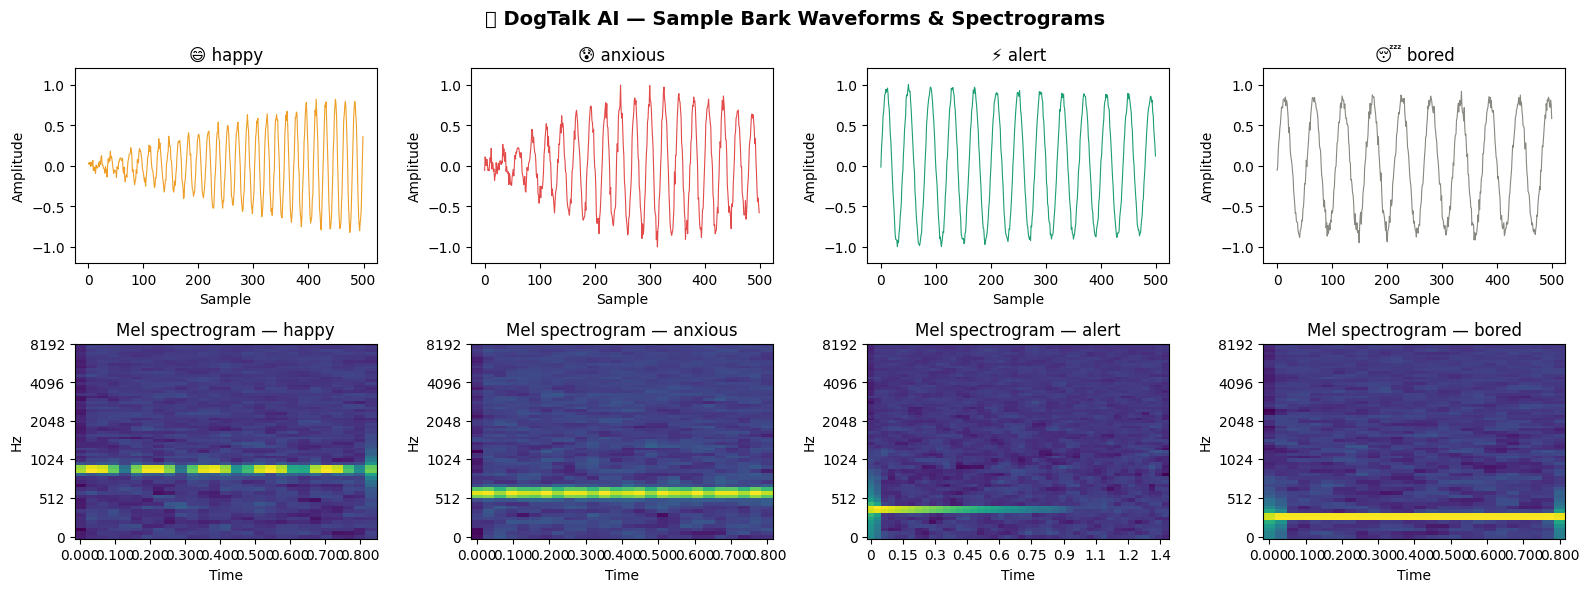

✅ Saved: dogtalk_spectrograms.png


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('🐶 DogTalk AI — Sample Bark Waveforms & Spectrograms', fontsize=14, fontweight='bold')

for i, emotion in enumerate(EMOTIONS):
    sample = next(s for s in dataset if s['emotion'] == emotion)
    wave = sample['waveform']
    sr = 16000

    # Waveform
    axes[0][i].plot(wave[:500], color=['#EF9F27','#E24B4A','#1D9E75','#888780'][i], linewidth=0.8)
    axes[0][i].set_title(f'{EMOTION_EMOJI[emotion]} {emotion}', fontsize=12)
    axes[0][i].set_xlabel('Sample')
    axes[0][i].set_ylabel('Amplitude')
    axes[0][i].set_ylim(-1.2, 1.2)

    # Spectrogram
    S = librosa.feature.melspectrogram(y=wave, sr=sr, n_mels=64)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, ax=axes[1][i], x_axis='time', y_axis='mel', cmap='viridis')
    axes[1][i].set_title(f'Mel spectrogram — {emotion}')

plt.tight_layout()
plt.savefig('dogtalk_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: dogtalk_spectrograms.png')

### Step 5 — Extract wav2vec2 embeddings

In [6]:
def extract_embedding(waveform: np.ndarray, sr: int = 16000) -> torch.Tensor:
    """Extract mean-pooled wav2vec2 hidden states as feature vector."""
    inputs = processor(waveform, sampling_rate=sr, return_tensors='pt', padding=True)
    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = wav2vec2(input_values)
        hidden = outputs.last_hidden_state  # (1, seq_len, 768)
        embedding = hidden.mean(dim=1)     # (1, 768)

    return embedding.squeeze(0).cpu()

print('Extracting embeddings...')
embeddings = []
labels = []

for sample in dataset:
    emb = extract_embedding(sample['waveform'])
    embeddings.append(emb)
    labels.append(sample['label'])

X = torch.stack(embeddings)          # (40, 768)
y = torch.tensor(labels, dtype=torch.long)

print(f'✅ Embeddings shape: {X.shape}')

Extracting embeddings...
✅ Embeddings shape: torch.Size([40, 768])


### Step 6 — Train emotion classifier (fine-tuned head)

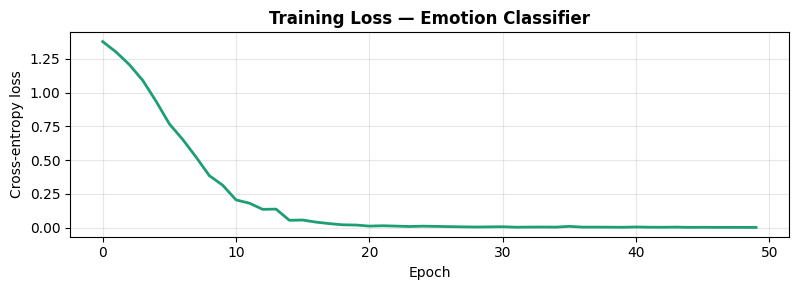

✅ Training complete. Final loss: 0.0014


In [7]:
# Train/test split (80/20)
from torch.utils.data import DataLoader, TensorDataset

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)

# Simple classifier head
class EmotionClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

classifier = EmotionClassifier().to(device)
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 50
losses = []

for epoch in range(EPOCHS):
    classifier.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = classifier(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_loader))

# Plot training curve
plt.figure(figsize=(8, 3))
plt.plot(losses, color='#1D9E75', linewidth=2)
plt.title('Training Loss — Emotion Classifier', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dogtalk_training_loss.png', dpi=150)
plt.show()
print(f'✅ Training complete. Final loss: {losses[-1]:.4f}')

### Step 7 — Evaluate Pipeline A

PIPELINE A — Classification Report
              precision    recall  f1-score   support

       happy       1.00      1.00      1.00         2
     anxious       1.00      1.00      1.00         4
       alert       1.00      1.00      1.00         1
       bored       1.00      1.00      1.00         1

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



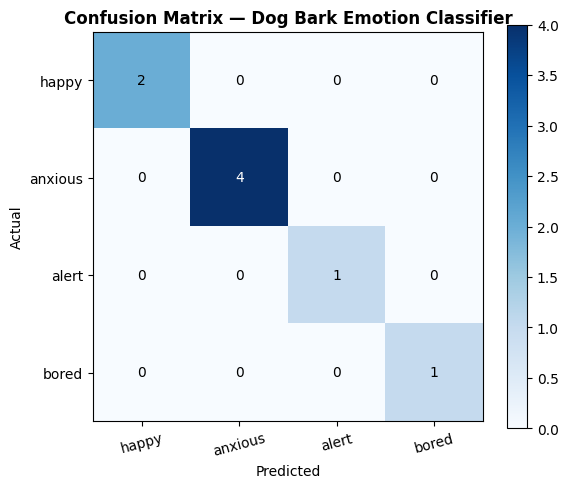

In [8]:
classifier.eval()
with torch.no_grad():
    logits = classifier(X_test.to(device))
    preds = logits.argmax(dim=1).cpu().numpy()
    true = y_test.numpy()
    probs = torch.softmax(logits, dim=1).cpu().numpy()

print('='*50)
print('PIPELINE A — Classification Report')
print('='*50)
print(classification_report(true, preds, target_names=EMOTIONS))

# Confusion matrix
cm = confusion_matrix(true, preds)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(4)); ax.set_xticklabels(EMOTIONS, rotation=15)
ax.set_yticks(range(4)); ax.set_yticklabels(EMOTIONS)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Dog Bark Emotion Classifier', fontweight='bold')
plt.colorbar(im, ax=ax)
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i][j]), ha='center', va='center',
                color='white' if cm[i][j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig('dogtalk_confusion_matrix.png', dpi=150)
plt.show()

### Step 8 — Real-time inference demo (Pipeline A)

In [9]:
def predict_emotion(waveform: np.ndarray, sr: int = 16000):
    """Predict dog emotion from a bark waveform."""
    emb = extract_embedding(waveform, sr).unsqueeze(0).to(device)
    classifier.eval()
    with torch.no_grad():
        logits = classifier(emb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred_idx = np.argmax(probs)

    print('\n🎵 Bark audio (play below):')
    display(Audio(waveform, rate=sr))

    print(f'\n🐶 DogTalk AI says: "{IDX_TO_EMOTION[pred_idx]}" {EMOTION_EMOJI[IDX_TO_EMOTION[pred_idx]]}')
    print(f'   Confidence: {probs[pred_idx]*100:.1f}%')
    print('\n   All scores:')
    for i, e in enumerate(EMOTIONS):
        bar = '█' * int(probs[i] * 20)
        print(f'   {EMOTION_EMOJI[e]} {e:8s} {bar:20s} {probs[i]*100:.1f}%')
    return IDX_TO_EMOTION[pred_idx], probs

# Demo on each emotion
for emotion in EMOTIONS:
    print('\n' + '─'*40)
    print(f'Testing with synthesized {emotion} bark...')
    wave = synthesize_bark(emotion)
    predict_emotion(wave)


────────────────────────────────────────
Testing with synthesized happy bark...

🎵 Bark audio (play below):



🐶 DogTalk AI says: "happy" 😄
   Confidence: 99.9%

   All scores:
   😄 happy    ███████████████████  99.9%
   😰 anxious                       0.0%
   ⚡ alert                         0.1%
   😴 bored                         0.0%

────────────────────────────────────────
Testing with synthesized anxious bark...

🎵 Bark audio (play below):



🐶 DogTalk AI says: "anxious" 😰
   Confidence: 99.5%

   All scores:
   😄 happy                         0.0%
   😰 anxious  ███████████████████  99.5%
   ⚡ alert                         0.4%
   😴 bored                         0.0%

────────────────────────────────────────
Testing with synthesized alert bark...

🎵 Bark audio (play below):



🐶 DogTalk AI says: "alert" ⚡
   Confidence: 97.8%

   All scores:
   😄 happy                         1.8%
   😰 anxious                       0.4%
   ⚡ alert    ███████████████████  97.8%
   😴 bored                         0.1%

────────────────────────────────────────
Testing with synthesized bored bark...

🎵 Bark audio (play below):



🐶 DogTalk AI says: "bored" 😴
   Confidence: 99.8%

   All scores:
   😄 happy                         0.0%
   😰 anxious                       0.0%
   ⚡ alert                         0.2%
   😴 bored    ███████████████████  99.8%
